# PCA Reconstruction — Anomaly Detection Baseline
### EngineFaultDB Dataset

PCA is used as the baseline for comparison against the autoencoder. Both methods
follow the same approach: train on healthy data only, reconstruct the input,
and use reconstruction error as the anomaly signal. The key difference is that
PCA performs linear dimensionality reduction while the autoencoder learns a
non-linear representation. This comparison directly answers whether non-linear
representation learning provides meaningful improvement over a classical linear approach.


In [1]:
import random
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import Normalizer, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, recall_score,
    precision_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)



## 1 · Data Loading

In [2]:
dataset = pd.read_csv('../data/EngineFaultDB_Final.csv')
print(f"Dataset shape: {dataset.shape}")
print()
print(dataset['Fault'].value_counts())


Dataset shape: (55999, 15)

Fault
0    16000
2    15000
3    14001
1    10998
Name: count, dtype: int64


## 2 · Preprocessing

In [3]:
# isolate healthy samples — PCA trains on healthy data only, same as the autoencoder
healthy_data  = dataset[dataset["Fault"] == 0].drop(columns=["Fault"])
healthy_input = healthy_data.values

healthy_train, healthy_test = train_test_split(
    healthy_input, test_size=0.2, random_state=SEED)

print(f"Train: {len(healthy_train)} | Test: {len(healthy_test)}")


Train: 12800 | Test: 3200


In [ ]:
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler())
])
pipeline.fit(healthy_train)

train_transformed = pipeline.transform(healthy_train)
test_transformed  = pipeline.transform(healthy_test)


In [5]:
# transform all three fault types using the same fitted pipeline
faulty_transformeddata  = pipeline.transform(
    dataset[dataset['Fault'] == 1].drop("Fault", axis=1).values)
faulty_transformeddata2 = pipeline.transform(
    dataset[dataset['Fault'] == 2].drop("Fault", axis=1).values)
faulty_transformeddata3 = pipeline.transform(
    dataset[dataset['Fault'] == 3].drop("Fault", axis=1).values)


## 3 · Realistic Test Set

Fault samples are subsampled to 200 per fault type (~17% overall fault rate).


In [6]:
N_PER_FAULT = 200

np.random.seed(SEED)
idx1 = np.random.choice(len(faulty_transformeddata),  N_PER_FAULT, replace=False)
idx2 = np.random.choice(len(faulty_transformeddata2), N_PER_FAULT, replace=False)
idx3 = np.random.choice(len(faulty_transformeddata3), N_PER_FAULT, replace=False)

fault_sample1 = faulty_transformeddata[idx1]
fault_sample2 = faulty_transformeddata2[idx2]
fault_sample3 = faulty_transformeddata3[idx3]

all_test = np.vstack([
    test_transformed,
    fault_sample1,
    fault_sample2,
    fault_sample3
])

all_labels = np.array(
    [0] * len(test_transformed) +
    [1] * N_PER_FAULT +
    [1] * N_PER_FAULT +
    [1] * N_PER_FAULT
)

fault_rate = (N_PER_FAULT * 3) / len(all_labels)
print(f"Healthy:    {len(test_transformed)}")
print(f"Fault:      {N_PER_FAULT * 3}")
print(f"Fault rate: {fault_rate:.1%}")


Healthy:    3200
Fault:      600
Fault rate: 15.8%


## 4 · PCA — Component Selection

PCA compresses the 14 sensor features into a lower-dimensional space and then
reconstructs back to 14 dimensions. The reconstruction error is the anomaly signal —
healthy data reconstructs well, fault data does not.



In [ ]:
# sweep component counts to find the best reconstruction on healthy validation data
component_results = {}
for n in [2, 3, 4, 5, 6]:
    pca_temp = PCA(n_components=n, random_state=SEED)
    pca_temp.fit(train_transformed)
    recon      = pca_temp.inverse_transform(pca_temp.transform(test_transformed))
    val_error  = np.mean(np.abs(test_transformed - recon))
    component_results[n] = val_error
    print(f"Components {n}: val reconstruction error = {val_error:.6f} "
          f"| variance explained = {pca_temp.explained_variance_ratio_.sum()*100:.1f}%")

best_n = min(component_results, key=component_results.get)
print(f"\nBest number of components: {best_n}")


Components 2: val reconstruction error = 0.421951 | variance explained = 65.3%
Components 3: val reconstruction error = 0.260092 | variance explained = 85.4%
Components 4: val reconstruction error = 0.217587 | variance explained = 91.4%
Components 5: val reconstruction error = 0.177078 | variance explained = 94.3%
Components 6: val reconstruction error = 0.139349 | variance explained = 96.2%

Best number of components: 6


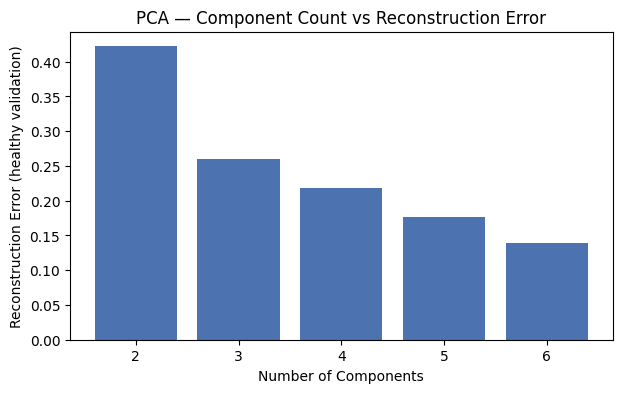

In [8]:
plt.figure(figsize=(7, 4))
plt.bar(component_results.keys(), component_results.values(), color="#4C72B0")
plt.xlabel("Number of Components")
plt.ylabel("Reconstruction Error (healthy validation)")
plt.title("PCA — Component Count vs Reconstruction Error")
plt.savefig("../figures/pca_component_tuning.png", bbox_inches="tight")
plt.show()


## 5 · Train Final PCA Model

In [9]:
pca = PCA(n_components=best_n, random_state=SEED)
pca.fit(train_transformed)

print(f"Components:        {best_n}")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"Per component:     {[round(v*100, 1) for v in pca.explained_variance_ratio_]}%")


Components:        6
Variance retained: 96.2%
Per component:     [np.float64(34.1), np.float64(31.2), np.float64(20.1), np.float64(6.0), np.float64(2.9), np.float64(2.0)]%


## 6 · Reconstruction Errors

In [10]:
def pca_reconstruction_error(data):
    recon = pca.inverse_transform(pca.transform(data))
    return np.mean(np.abs(data - recon), axis=1)

errors_healthy = pca_reconstruction_error(test_transformed)
errors_fault1  = pca_reconstruction_error(fault_sample1)
errors_fault2  = pca_reconstruction_error(fault_sample2)
errors_fault3  = pca_reconstruction_error(fault_sample3)

print(f"Avg reconstruction error - Healthy: {np.mean(errors_healthy):.6f}")
print(f"Avg reconstruction error - Fault 1: {np.mean(errors_fault1):.6f}")
print(f"Avg reconstruction error - Fault 2: {np.mean(errors_fault2):.6f}")
print(f"Avg reconstruction error - Fault 3: {np.mean(errors_fault3):.6f}")
print()
for name, err in [("Fault 1", errors_fault1),
                  ("Fault 2", errors_fault2),
                  ("Fault 3", errors_fault3)]:
    diff = np.mean(err) - np.mean(errors_healthy)
    print(f"{name}: avg error {np.mean(err):.4f} (+{diff:.4f} above healthy mean)")


Avg reconstruction error - Healthy: 0.139349
Avg reconstruction error - Fault 1: 0.316078
Avg reconstruction error - Fault 2: 0.296822
Avg reconstruction error - Fault 3: 0.320682

Fault 1: avg error 0.3161 (+0.1767 above healthy mean)
Fault 2: avg error 0.2968 (+0.1575 above healthy mean)
Fault 3: avg error 0.3207 (+0.1813 above healthy mean)


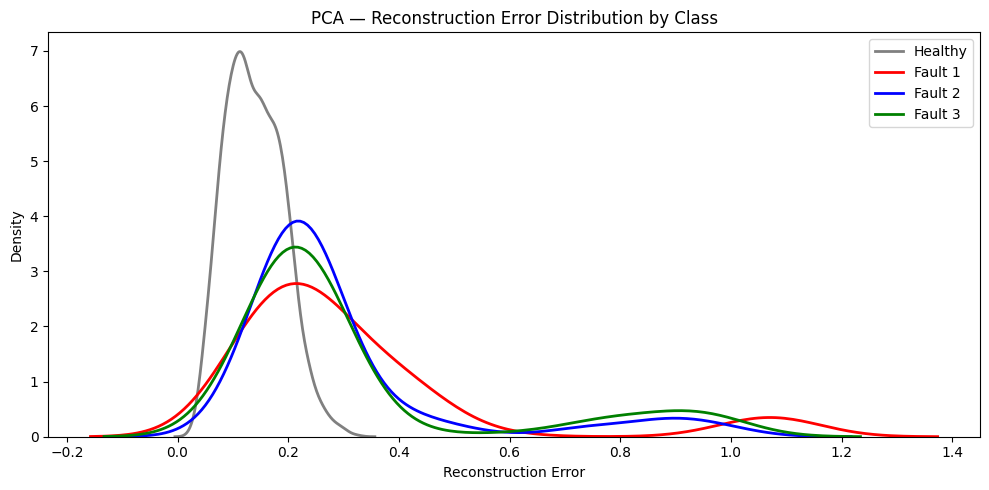

In [11]:
plt.figure(figsize=(10, 5))
for err, label, color in [
    (errors_healthy, "Healthy", "grey"),
    (errors_fault1,  "Fault 1", "red"),
    (errors_fault2,  "Fault 2", "blue"),
    (errors_fault3,  "Fault 3", "green"),
]:
    sns.kdeplot(err, label=label, color=color, linewidth=2)

plt.xlabel("Reconstruction Error")
plt.title("PCA — Reconstruction Error Distribution by Class")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/pca_error_distribution.png", bbox_inches="tight")
plt.show()


## 7 · Threshold Optimization

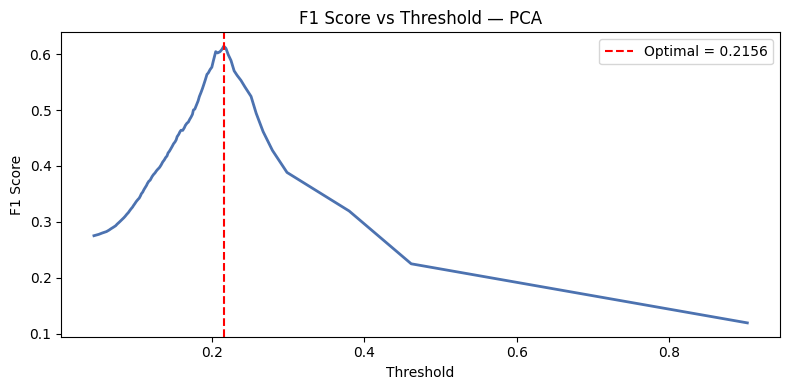

Optimal threshold: 0.2156
Best F1:           0.6142


In [12]:
# get reconstruction errors on the full combined test set
pca_errors = pca_reconstruction_error(all_test)

# optimize threshold using F1 — same strategy as the autoencoder notebook
thresholds_pca = np.percentile(pca_errors, np.arange(1, 100, 1))
f1_scores_pca  = [f1_score(all_labels, (pca_errors > t).astype(int))
                  for t in thresholds_pca]

optimal_threshold_pca = thresholds_pca[np.argmax(f1_scores_pca)]
preds_pca             = (pca_errors > optimal_threshold_pca).astype(int)

plt.figure(figsize=(8, 4))
plt.plot(thresholds_pca, f1_scores_pca, color="#4C72B0", linewidth=2)
plt.axvline(optimal_threshold_pca, color="red", linestyle="--",
            label=f"Optimal = {optimal_threshold_pca:.4f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold — PCA")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/pca_threshold_optimization.png", bbox_inches="tight")
plt.show()

print(f"Optimal threshold: {optimal_threshold_pca:.4f}")
print(f"Best F1:           {max(f1_scores_pca):.4f}")


## 8 · Evaluation

In [13]:
roc_auc_pca   = roc_auc_score(all_labels, pca_errors)
f1_pca        = f1_score(all_labels, preds_pca)
recall_pca    = recall_score(all_labels, preds_pca)
precision_pca = precision_score(all_labels, preds_pca)

print("=== PCA Baseline Results ===")
print(f"ROC-AUC:   {roc_auc_pca:.4f}")
print(f"F1:        {f1_pca:.4f}")
print(f"Recall:    {recall_pca:.4f}")
print(f"Precision: {precision_pca:.4f}")


=== PCA Baseline Results ===
ROC-AUC:   0.8717
F1:        0.6142
Recall:    0.6183
Precision: 0.6102


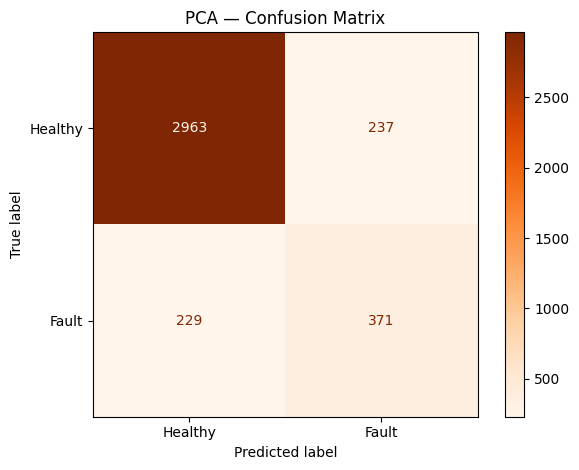

In [14]:
ConfusionMatrixDisplay(
    confusion_matrix(all_labels, preds_pca),
    display_labels=["Healthy", "Fault"]
).plot(cmap="Oranges")
plt.title("PCA — Confusion Matrix")
plt.tight_layout()
plt.savefig("../figures/pca_confusion_matrix.png", bbox_inches="tight")
plt.show()


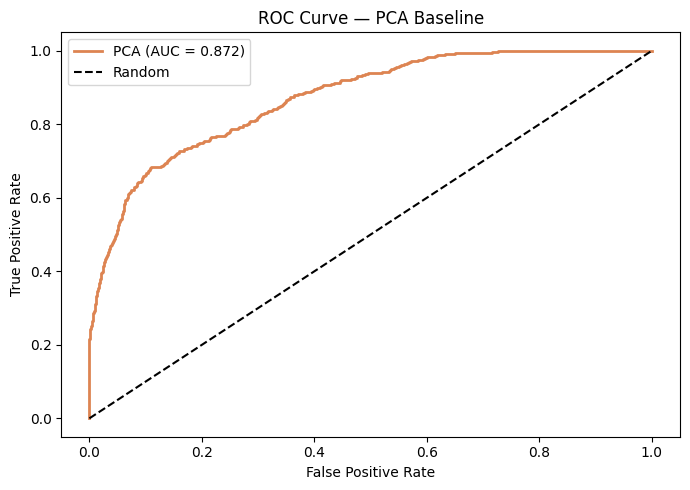

In [15]:
fpr_pca, tpr_pca, _ = roc_curve(all_labels, pca_errors)

plt.figure(figsize=(7, 5))
plt.plot(fpr_pca, tpr_pca, color="#DD8452", linewidth=2,
         label=f"PCA (AUC = {roc_auc_pca:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — PCA Baseline")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/roc_curve_pca.png", bbox_inches="tight")
plt.show()


In [16]:
joblib.dump(pca,      "../models/pca_baseline.pkl")
joblib.dump(pipeline, "../models/pipeline.pkl")
print("Saved → ../models/pca_baseline.pkl")


Saved → ../models/pca_baseline.pkl
